
# Tutorial 11 — **Detección de outliers** y **efecto en modelos**


**Objetivo**: Detectar outliers con **Z‑score** e **IQR**, **visualizarlos** (boxplot, hist, dispersión), **limpiarlos** (eliminación/recorte) y comparar el **desempeño de modelos** antes y después de tratarlos.




<a id="material"></a>
## 1) Material de estudio



<a id="que-es"></a>
### 1.1 ¿Qué es un outlier y por qué importa?
Un **outlier** es una observación que se aleja notablemente del patrón general de los datos. Puede **distorsionar** estadísticas (media, desviación) y **afectar** el entrenamiento de modelos (coeficientes, fronteras, reglas), por lo que conviene **diagnosticarlos** antes de modelar.




<a id="metodos"></a>
### 1.2 Métodos de detección (fórmulas)
- **Z‑score** clásico: \(z_i = $\frac{x_i - \mu}{\sigma}$). Marcamos outliers si \(|z_i| $> 3$\) (umbral típico).  
- **IQR**: calcular **Q1**, **Q3** e **IQR = Q3 − Q1**; límites: **LI = Q1 − 1.5·IQR**, **LS = Q3 + 1.5·IQR**. Valores fuera de \([LI, LS]\) se consideran outliers.
> Nota: en datos sesgados, usar medidas **robustas** (mediana y **MAD**) para un z‑score robusto puede ser más estable.



<a id="viz"></a>
### 1.3 Visualización de apoyo
- **Boxplot** e **histograma** para una variable.  
- **Dispersión** (scatter) para ver puntos alejados en 2D/3D.



<a id="estrategias"></a>
### 1.4 ¿Eliminar o transformar?
- **Eliminar**: descartar puntos extremos (si son errores o no representan el fenómeno).  
- **Transformar**: p. ej., **log** para atenuar colas derechas.
> Elegir según **contexto** (calidad de dato vs caso real extremo) y **objetivo** (descriptivo vs predictivo).


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Tuple

def zscore_flags(s: pd.Series, threshold: float = 3.0) -> pd.Series:
    """Devuelve una serie booleana True para outliers por Z-score clásico."""
    mu, sigma = s.mean(), s.std(ddof=1)
    if sigma == 0 or np.isnan(sigma):
        return pd.Series([False]*len(s), index=s.index)
    z = (s - mu) / sigma
    return z.abs() > threshold

def iqr_bounds(s: pd.Series, k: float = 1.5) -> Tuple[float, float]:
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

def iqr_flags(s: pd.Series, k: float = 1.5) -> pd.Series:
    li, ls = iqr_bounds(s, k=k)
    return (s < li) | (s > ls)


Ejemplo 1D con outliers (valores extremos inyectados).
Resumen: {'count': 300.0, 'mean': 99.84113050136185, 'std': 17.039342198839424, 'min': 10.0, '25%': 89.95953000148741, '50%': 99.2221865364657, '75%': 107.2345467156374, 'max': 220.0}


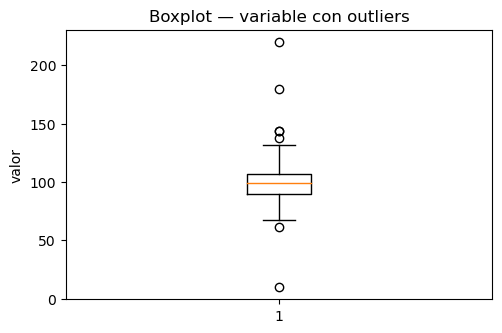

In [2]:
# Demostración rápida 1D: variable con outliers y sus gráficos

rng = np.random.default_rng(42)
x = pd.Series(rng.normal(100, 15, size=300))
# Inyectamos algunos outliers
x.iloc[[5, 25, 150]] = [180, 10, 220]

print("Ejemplo 1D con outliers (valores extremos inyectados).")
print("Resumen:", x.describe().to_dict())

# Boxplot
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.boxplot(x, vert=True)
ax.set_title("Boxplot — variable con outliers")
ax.set_ylabel("valor")
plt.show()


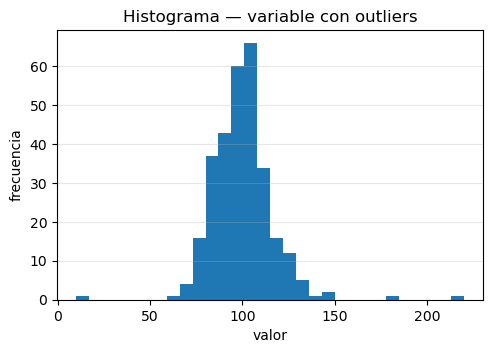

In [3]:
# Histograma
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.hist(x, bins=30)
ax.set_title("Histograma — variable con outliers")
ax.set_xlabel("valor"); ax.set_ylabel("frecuencia")
ax.grid(axis="y", alpha=0.3)
plt.show()


<a id="ejemplos"></a>
## 2) Ejemplos



<a id="regresion"></a>
### 2.1 Regresión — impacto de outliers y limpieza

**Datos**: simulamos \(y = 3x + $\epsilon$\) y añadimos outliers grandes en `y`.  
**Modelos**: `LinearRegression` antes y después de limpiar **outliers (IQR/Z)**.  
**Métricas**: `R²`, `MAE`, `RMSE` sobre *test*. Además, visualizamos **y_real vs y_pred**.


In [4]:

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [5]:
# 1) Datos LIMPIOS primero (sin outliers)
rng = np.random.default_rng(0)
n = 450
X = rng.normal(0, 1, size=n).reshape(-1, 1)
#y_clean = 3*X.ravel() + rng.normal(0, 1.2, size=n)
y = 3*X.ravel() + rng.normal(0, 1.2, size=n)

# 2) Inyectar OUTLIERS (afecta train y test)
ratio_out = 0.20
mu_shift  = 50.0        # magnitud típica del desplazamiento
sd_shift  = 20.0        # dispersión del desplazamiento


n_out = max(1, int(n * ratio_out))
idx_out = rng.choice(n, size=n_out, replace=False)

# Ruido grande (con signo aleatorio; más positivos que negativos)
sign = rng.choice([-1, 1], size=n_out, p=[0.4, 0.6])
big_noise = sign * rng.normal(mu_shift, sd_shift, size=n_out)

# Inyectar outliers en y
y_cont = y.copy()
y_cont[idx_out] += big_noise


# Máscara “verdad” de outliers (solo para análisis/plots, NO para limpiar)
is_outlier = np.zeros(n, dtype=bool)
is_outlier[idx_out] = True

print("Creando dataset de REGRESIÓN con outliers en el target y...")
print("Total muestras:", n, "| Outliers inyectados:", len(idx_out))


Creando dataset de REGRESIÓN con outliers en el target y...
Total muestras: 450 | Outliers inyectados: 90


In [6]:
Xtr, Xte, ytr, yte, mtr, mte = train_test_split(X, y_cont, is_outlier, test_size=0.25, random_state=42, stratify=is_outlier)

Desempeño BASE (con outliers):
  R^2=-0.062 | MAE=12.756 | RMSE=26.544


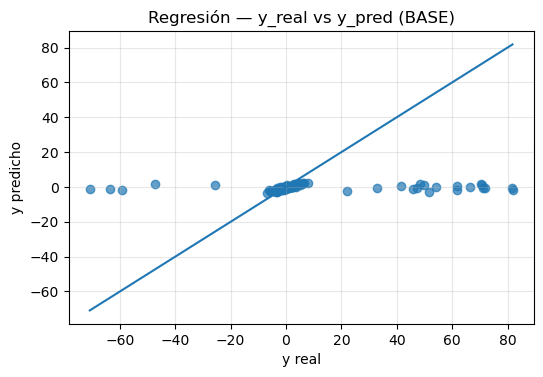

In [7]:
def eval_reg(y_true, y_pred, prefix=""):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{prefix}R^2={r2:.3f} | MAE={mae:.3f} | RMSE={rmse:.3f}")
    return r2, mae, rmse

# Modelo base (con outliers)
lr = LinearRegression().fit(Xtr, ytr)
pred_te = lr.predict(Xte)
print("Desempeño BASE (con outliers):")
eval_reg(yte, pred_te, prefix="  ")

# Visualizar y_real vs y_pred (base)

fig, ax = plt.subplots(figsize=(6.0, 3.8))
ax.scatter(yte, pred_te, alpha=0.7)
mn, mx = min(yte.min(), pred_te.min()), max(yte.max(), pred_te.max())
ax.plot([mn, mx], [mn, mx])
ax.set_title("Regresión — y_real vs y_pred (BASE)")
ax.set_xlabel("y real"); ax.set_ylabel("y predicho")
ax.grid(True, alpha=0.3)
plt.show()

Limpieza por IQR en y sobre TRAIN: removidas 66 filas.
Desempeño tras limpiar por IQR:
  R^2=-0.049 | MAE=12.219 | RMSE=26.381
Limpieza por Z-score en y sobre TRAIN: removidas 5 filas.
Desempeño tras limpiar por Z-score:
  R^2=-0.056 | MAE=12.672 | RMSE=26.471


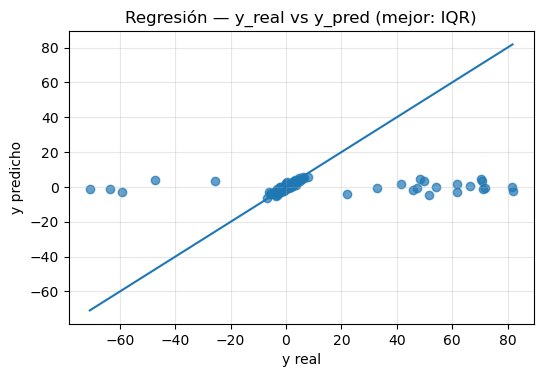

In [8]:
# Limpieza por IQR en y (sólo sobre TRAIN para evitar fuga)
ytr_s = pd.Series(ytr)
mask_iqr = ~iqr_flags(ytr_s, k=1.5)
Xtr_iqr = Xtr[mask_iqr.values]
ytr_iqr = ytr[mask_iqr.values]
print("Limpieza por IQR en y sobre TRAIN: removidas", (~mask_iqr).sum(), "filas.")

lr_iqr = LinearRegression().fit(Xtr_iqr, ytr_iqr)
pred_te_iqr = lr_iqr.predict(Xte)
print("Desempeño tras limpiar por IQR:")
eval_reg(yte, pred_te_iqr, prefix="  ")

# Limpieza por Z-score (umbral 3) en y (TRAIN)
mask_z = ~zscore_flags(ytr_s, threshold=3.0)
Xtr_z = Xtr[mask_z.values]
ytr_z = ytr[mask_z.values]
print("Limpieza por Z-score en y sobre TRAIN: removidas", (~mask_z).sum(), "filas.")

lr_z = LinearRegression().fit(Xtr_z, ytr_z)
pred_te_z = lr_z.predict(Xte)
print("Desempeño tras limpiar por Z-score:")
eval_reg(yte, pred_te_z, prefix="  ")

# Visualizar y_real vs y_pred (mejor variante)
# Elegimos el que tenga mejor R2 en test
r2_base = r2_score(yte, pred_te)
r2_iqr  = r2_score(yte, pred_te_iqr)
r2_z    = r2_score(yte, pred_te_z)
best_name, best_pred = max(
    [("BASE", pred_te), ("IQR", pred_te_iqr), ("Z-score", pred_te_z)],
    key=lambda kv: r2_score(yte, kv[1])
)

fig, ax = plt.subplots(figsize=(6.0, 3.8))
ax.scatter(yte, best_pred, alpha=0.7)
mn, mx = min(yte.min(), best_pred.min()), max(yte.max(), best_pred.max())
ax.plot([mn, mx], [mn, mx])
ax.set_title(f"Regresión — y_real vs y_pred (mejor: {best_name})")
ax.set_xlabel("y real"); ax.set_ylabel("y predicho")
ax.grid(True, alpha=0.3)
plt.show()



<a id="clasificacion"></a>
### 2.2 Clasificación — ruido extremo y limpieza

**Datos**: dos *blobs* bien separados + puntos **extremos** (outliers) uniformes en el espacio.  
**Modelo**: `LogisticRegression` antes y después de limpiar por **Z‑score** en *features* (TRAIN).  
**Métricas**: `accuracy` y `f1`; visualizamos **matriz de confusión**.


Clasificación con LogisticRegression — BASE (con outliers):
  Accuracy=0.924 | F1=0.922


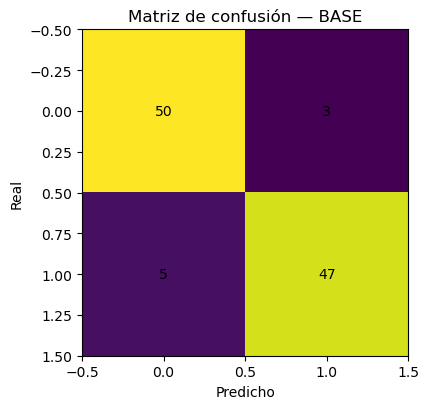

In [9]:

from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(1)
Xb, yb = make_blobs(n_samples=380, centers=2, n_features=2, cluster_std=1.2, random_state=0)

# Inyectamos outliers (con etiquetas aleatorias para "ensuciar")
n_out = 40
out = rng.uniform(low=-10, high=10, size=(n_out, 2))
y_out = rng.integers(0, 2, size=n_out)
Xc = np.vstack([Xb, out])
yc = np.concatenate([yb, y_out])

Xtr, Xte, ytr, yte = train_test_split(Xc, yc, test_size=0.25, random_state=40, stratify=yc)

def eval_clf(y_true, y_pred, prefix=""):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"{prefix}Accuracy={acc:.3f} | F1={f1:.3f}")
    return acc, f1

print("Clasificación con LogisticRegression — BASE (con outliers):")
clf = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
yp = clf.predict(Xte)
eval_clf(yte, yp, prefix="  ")

# Matriz de confusión base
cm = confusion_matrix(yte, yp)
fig, ax = plt.subplots(figsize=(5.2, 4.2))
ax.imshow(cm)
ax.set_title("Matriz de confusión — BASE")
ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()


Limpieza por Z-score en TRAIN: removidas 13 filas.
Tras limpieza (Z‑score en features):
  Accuracy=0.924 | F1=0.922


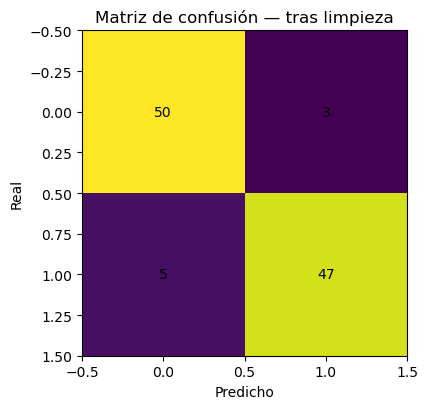

In [10]:
# Limpieza por Z-score sobre TRAIN (en cada feature)
Xtr_df = pd.DataFrame(Xtr, columns=["f1","f2"])
mask_z = ~(zscore_flags(Xtr_df["f1"], 3.0) | zscore_flags(Xtr_df["f2"], 3.0))
print("Limpieza por Z-score en TRAIN: removidas", (~mask_z).sum(), "filas.")

clf2 = LogisticRegression(max_iter=1000).fit(Xtr_df.loc[mask_z].values, ytr[mask_z.values])
yp2 = clf2.predict(Xte)
print("Tras limpieza (Z‑score en features):")
eval_clf(yte, yp2, prefix="  ")

# Matriz de confusión limpia
cm2 = confusion_matrix(yte, yp2)
fig, ax = plt.subplots(figsize=(5.2, 4.2))
ax.imshow(cm2)
ax.set_title("Matriz de confusión — tras limpieza")
ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
for i in range(cm2.shape[0]):
    for j in range(cm2.shape[1]):
        ax.text(j, i, cm2[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()  


<a id="ejercicios"></a>
## 3) Ejercicios

> **Formato**: usa `print(...)` **descriptivos** y figuras con títulos/ejes/leyendas.



### Ejercicio 1 — Funciones de outliers reutilizables
Implementa `detectar_outliers_z(df, cols, thr)` y `detectar_outliers_iqr(df, cols, k)` que devuelvan **índices** a eliminar. Pruébalas en el dataset de clasificación y compara `accuracy`/`F1`.


In [11]:

# Tu solución aquí



### Ejercicio 2 — Umbrales y sensibilidad
Explora distintos **umbrales**: `k ∈ {1.0, 1.5, 2.0}` para IQR y `thr ∈ {2.5, 3.0, 3.5}` para Z‑score. ¿Qué umbral equilibra mejor desempeño y tamaño de la muestra?


In [12]:

# Tu solución aquí
# Sugerencia: en bucle, genera métricas y guarda resultados en un DataFrame para comparar.


### Ejercicio 3 — Visualizaciones antes/después
Crea **boxplot** e **histogramas** de una variable antes y después de limpiar; en clasificación, compara **matrices de confusión**.
